In [13]:
pip install faker

In [14]:
fake = Faker()

In [15]:
from faker import Faker


In [16]:
num_students = 250
departments = ['CSE', 'IT', 'ECE']
years = ['1st', '2nd', '3rd']
genders = ['Male', 'Female']

data = []

for i in range(num_students):
    student = {
        "Student_ID": 1000 + i,
        "Name": fake.name(),
        "Gender": random.choice(genders),
        "Department": random.choice(departments),
        "Year": random.choice(years),
        "Maths": random.randint(35, 100),
        "Science": random.randint(35, 100),
        "English": random.randint(35, 100),
        "Attendance (%)": random.randint(50, 100),
        "Internal Marks": random.randint(0, 25)
    }
    data.append(student)

df = pd.DataFrame(data)

print("Dataset Created Successfully\n")
print(df.head())

Dataset Created Successfully

   Student_ID             Name  Gender Department Year  Maths  Science  \
0        1000     Steven Burke    Male        CSE  1st     84       94   
1        1001    Taylor Miller  Female        ECE  2nd     93       71   
2        1002        Tom Young  Female        ECE  3rd     50       86   
3        1003  Stacey Mitchell    Male         IT  2nd     52       49   
4        1004   Aaron Franklin    Male        ECE  3rd     43       59   

   English  Attendance (%)  Internal Marks  
0       39              63               8  
1       50              95              11  
2       71              81               0  
3       86              81              11  
4       82              96              25  


In [17]:
print("\nMissing Values:\n", df.isnull().sum())
df.fillna(0, inplace=True)


Missing Values:
 Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance (%)    0
Internal Marks    0
dtype: int64


In [18]:
df["Total Marks"] = df["Maths"] + df["Science"] + df["English"]
df["Average Marks"] = df["Total Marks"] / 3

def grade(avg):
    if avg >= 85:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 50:
        return 'C'
    else:
        return 'Fail'

df["Grade"] = df["Average Marks"].apply(grade)

In [19]:
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
         Student_ID       Maths     Science     English  Attendance (%)  \
count   250.000000  250.000000  250.000000  250.000000       250.00000   
mean   1124.500000   68.472000   65.456000   67.316000        75.73200   
std      72.312977   17.960499   19.411628   19.708522        14.44322   
min    1000.000000   36.000000   35.000000   35.000000        50.00000   
25%    1062.250000   54.000000   48.000000   50.250000        64.00000   
50%    1124.500000   66.000000   65.000000   66.000000        77.00000   
75%    1186.750000   83.750000   80.750000   84.750000        88.00000   
max    1249.000000  100.000000  100.000000  100.000000       100.00000   

       Internal Marks  Total Marks  Average Marks  
count      250.000000   250.000000     250.000000  
mean        11.952000   201.244000      67.081333  
std          7.604011    34.868434      11.622811  
min          0.000000   118.000000      39.333333  
25%          5.250000   177.000000      59.0000

In [20]:
top_students = df.sort_values(by="Average Marks", ascending=False).head(10)
print("\nTop 10 Students:\n", top_students[["Name", "Average Marks"]])

fail_students = df[df["Grade"] == "Fail"]
print("\nFail Students:\n", fail_students[["Name", "Average Marks"]])


Top 10 Students:
                    Name  Average Marks
28     Michael Martinez      95.666667
101        Jeffery Hunt      95.666667
175     Brittany Warren      94.333333
212         Lisa Dawson      92.333333
109  Raymond Vazquez MD      91.000000
90        Sandra Miller      90.000000
53    Brittany Erickson      90.000000
133      Angela Lambert      89.333333
96       Crystal Hudson      89.333333
240          Cody Baker      88.666667

Fail Students:
                  Name  Average Marks
21      Nicole Miller      49.666667
40   Deborah Guerrero      45.666667
66        Joshua Rush      49.000000
94      Howard Brooks      49.000000
111      Melissa Reid      47.666667
122     Tamara Morgan      47.000000
129     Kelly Serrano      48.333333
131    Anthony Galvan      48.333333
136  Kenneth Reynolds      49.333333
141     Terri Lindsey      40.333333
149  Anthony Lamb DDS      43.333333
197      Erica Dawson      39.333333
214       Kelsey Pope      48.000000
222    Anthony Ma

In [21]:
print("\nDepartment-wise Performance:\n", df.groupby("Department")["Average Marks"].mean())

print("\nGender-wise Performance:\n", df.groupby("Gender")["Average Marks"].mean())

print("\nYear-wise Performance:\n", df.groupby("Year")["Average Marks"].mean())


Department-wise Performance:
 Department
CSE    67.468992
ECE    66.961039
IT     66.804598
Name: Average Marks, dtype: float64

Gender-wise Performance:
 Gender
Female    66.931129
Male      67.222222
Name: Average Marks, dtype: float64

Year-wise Performance:
 Year
1st    66.917603
2nd    67.705628
3rd    66.682540
Name: Average Marks, dtype: float64


In [22]:
correlation = df[["Attendance (%)", "Internal Marks", "Average Marks"]].corr()
print("\nCorrelation Matrix:\n", correlation)


Correlation Matrix:
                 Attendance (%)  Internal Marks  Average Marks
Attendance (%)        1.000000        0.063290      -0.143227
Internal Marks        0.063290        1.000000       0.078415
Average Marks        -0.143227        0.078415       1.000000


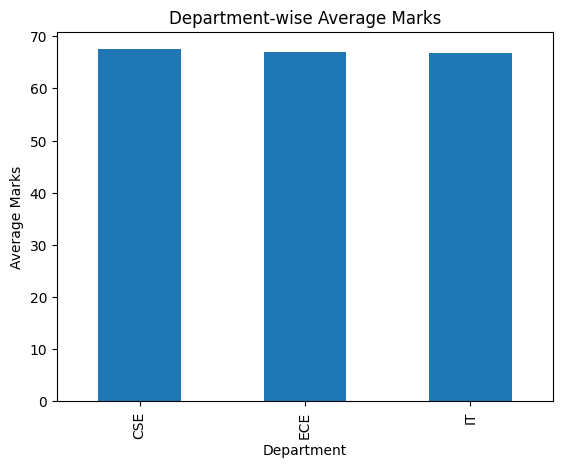

In [23]:
df.groupby("Department")["Average Marks"].mean().plot(kind='bar', title="Department-wise Average Marks")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

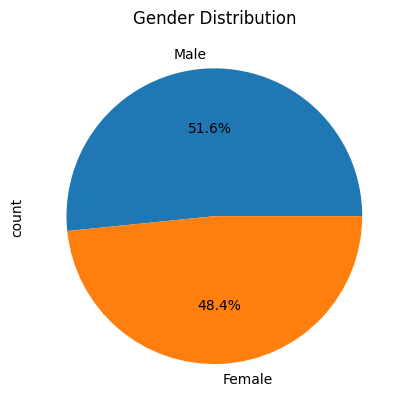

In [24]:
df["Gender"].value_counts().plot(kind='pie', autopct='%1.1f%%', title="Gender Distribution")
plt.show()

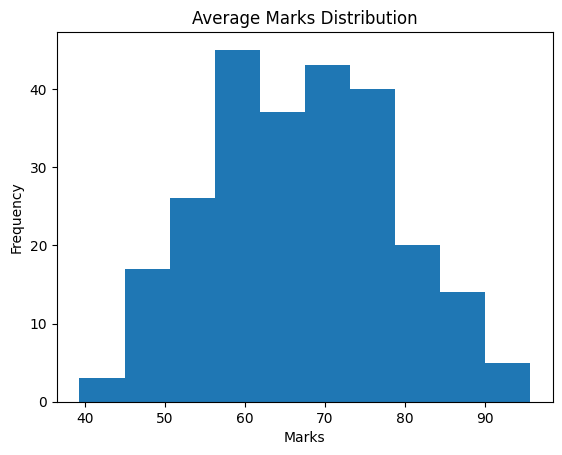

In [25]:
plt.hist(df["Average Marks"], bins=10)
plt.title("Average Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

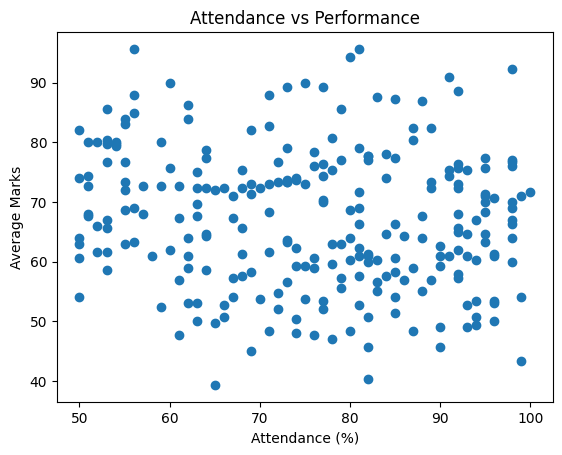

In [26]:
plt.scatter(df["Attendance (%)"], df["Average Marks"])
plt.xlabel("Attendance (%)")
plt.ylabel("Average Marks")
plt.title("Attendance vs Performance")
plt.show()


In [27]:
df.to_csv("student_performance_data.csv", index=False)
print("\nDataset saved as student_performance_data.csv")


Dataset saved as student_performance_data.csv
